# Entrega 1 Proyecto Aprendizaje de Máquina
**Grupo 50**

Integrantes
- Juan David Guzmán Casadiego
- Cristian Felipe Ochoa Osorio
- Emmanuel Felipe Blanco Corredor
- David Alfonso Perez

In [213]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression,Ridge,Lasso
from sklearn.metrics import classification_report, mean_absolute_error, root_mean_squared_error

## Carga de datos

In [192]:
data_train = pd.read_csv("./data/train.csv",encoding="utf-8")
data_eval = pd.read_csv("./data/eval.csv",encoding="utf-8")
print("Dimensiones data_train:",data_train.shape)
print("Dimensiones dara_eval",data_eval.shape)
data_train

Dimensiones data_train: (31403, 2)
Dimensiones dara_eval (3490, 2)


,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166
...,...,...
31398,N | Ml Luce Ll... ree de ha Ja ae e] bsupk : \...,164
31399,Haz que feas primero y tomar quiera ^ \...,155
31400,©da flota guarnecioa oage/aDa-fé?. lrv>. \n©do...,151
31401,"ríidc Valen! vn pcdafodel lignum Crucis, que e...",160


## Exploración de datos

No hay datos nulos o vacios, este no va a ser un problema

In [150]:
data_train.isnull().sum()/len(data_train) * 100

text      0.0
decade    0.0
dtype: float64

El formato de las decadas tampoco presenta problemas

In [151]:
data_train["decade"].value_counts()

decade
160    848
172    842
155    836
170    833
167    831
178    831
154    830
157    827
163    827
180    825
168    822
175    817
171    816
165    814
151    812
188    809
179    809
182    808
162    808
174    807
164    804
185    803
184    802
173    802
159    802
181    795
183    794
156    792
161    787
187    787
150    786
152    785
177    782
166    779
158    778
153    775
186    773
169    771
176    754
Name: count, dtype: int64

### Revision de los textos

In [193]:
print(data_train["text"][100])
print("\n")
print(data_train["text"][229])
print("\n")
print(data_train["text"][50])
print("\n")
print(data_train["text"][1000])
print("\n")
print(data_train["text"][2340])
print("\n")
print(data_train["text"][10675])

Efto fé ha viña en el Confejo de Portagal,c\ qual 
pbí M0'fé ; r precedido del de Aragón , nunca ha queri- 
do concurrir éfl 1 asProce fsione s , be lámanos , ni jun- 


| rres fecasy"carcilaginofes alí Tr 
Mieren:las medicinas y afidor 
He Toanisferapionisinfermos A 
Mde'vulneribus capitulo: pri- 


quartañJo en todo el difcuifodclaño . A«rora 
Ertcareci 9^*^ Ihoios dicíio dcl fcmbrar,vcamos con o he 
n,.<iuz^¿¿\ niü$ dclembrar y con que rcqiiífnos , para que 
yo cumpla lo que en U cab-^ de fte capitulo he 
propucfto^quccicrtoquc poraucrlo prouado, 
entiendo que ha di fcr de tanto aproucchamic- 
to en toda Efpaña como f; mótá todos los ditz 
mos^y los pechos, y las de mas gabelas que a fit 
Mageftad fe pigan cada ano^de todo lo qual de 
ucmos dar infinitas gracias al niñolES VS,cu 
ya es efta obra.y digo q quando viene !a fi nen- 
ccra,y todos empichan a fembrar con gran codi 
cii,has de yr tu a ver tus hazas, y en las que vic 
rcn que nafce el pelillo de la yci ua , y otras fix» 
fta

Para revisar más a fondo los textos, revisaremos qué tantos caracteres extraños hay en cada entrada

In [194]:
import re
patron = r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ0-9\s]"
data_train["ruido"] = data_train["text"].str.count(patron)

In [195]:
data_train["longitud"] = data_train["text"].str.len()

In [196]:
data_train.head(10)

,text,decade,ruido,longitud
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164,26,219
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182,19,355
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157,5,153
3,Caistro el M a y o r a i .] Del ape...,163,9,310
4,\nlos que panden macho ; y \notros en l...,166,35,1125
5,za subitánea di mió fratella. Ah s^egli fosse ...,183,5,175
6,\n- 47 — \n— Ídem el capitán de fiaxata ...,184,10,121
7,^H^.. vnacopaDemeDioanao(la.©efDccaboDemigiola...,151,39,735
8,"Fórmase en cada falda un ancho seno , \n...",184,5,167
9,"1 La xxij. h f Defcomulga,con refevuacio.al...",155,18,351


In [197]:
data_train["ratio_ruido"] = data_train["ruido"]/data_train["longitud"]

In [198]:
data_train.head(10)

,text,decade,ruido,longitud,ratio_ruido
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164,26,219,0.118721
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182,19,355,0.053521
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157,5,153,0.032680
3,Caistro el M a y o r a i .] Del ape...,163,9,310,0.029032
4,\nlos que panden macho ; y \notros en l...,166,35,1125,0.031111
5,za subitánea di mió fratella. Ah s^egli fosse ...,183,5,175,0.028571
6,\n- 47 — \n— Ídem el capitán de fiaxata ...,184,10,121,0.082645
7,^H^.. vnacopaDemeDioanao(la.©efDccaboDemigiola...,151,39,735,0.053061
8,"Fórmase en cada falda un ancho seno , \n...",184,5,167,0.029940
9,"1 La xxij. h f Defcomulga,con refevuacio.al...",155,18,351,0.051282


In [199]:
data_train.describe()

,decade,ruido,longitud,ratio_ruido
count,31403.000000,31403.000000,31403.000000,31403.000000
mean,168.972614,22.715091,520.568290,0.048763
std,11.222470,23.380435,530.947792,0.031064
min,150.000000,0.000000,120.000000,0.000000
25%,159.000000,8.000000,182.000000,0.030134
50%,169.000000,15.000000,315.000000,0.040984
75%,179.000000,29.000000,643.000000,0.057915
max,188.000000,349.000000,7418.000000,0.566929


In [200]:
agrupacion = np.where(data_train["ratio_ruido"]>=0.20,"Poco legible","Legible")
data_train.groupby(agrupacion)["ratio_ruido"].count()

Legible         31230
Poco legible      173
Name: ratio_ruido, dtype: int64

In [201]:
data_train.groupby("decade")["ratio_ruido"].mean()

decade
150    0.040053
151    0.052938
152    0.039776
153    0.053922
154    0.041109
155    0.043329
156    0.047509
157    0.049020
158    0.044842
159    0.042219
160    0.055937
161    0.052660
162    0.049163
163    0.056000
164    0.053867
165    0.055957
166    0.056617
167    0.056659
168    0.053765
169    0.055700
170    0.057954
171    0.056560
172    0.055765
173    0.055595
174    0.054827
175    0.047693
176    0.049920
177    0.051361
178    0.047457
179    0.046756
180    0.049010
181    0.043965
182    0.049169
183    0.040809
184    0.042581
185    0.039595
186    0.038778
187    0.036528
188    0.034635
Name: ratio_ruido, dtype: float64

In [202]:
bins = [0, 0.1, 0.25, 1]
labels = ["bajo", "medio", "alto"]

data_train["categoria_ruido"] = pd.cut(data_train["ratio_ruido"], bins=bins, labels=labels)
data_train.head(10)

,text,decade,ruido,longitud,ratio_ruido,categoria_ruido
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164,26,219,0.118721,medio
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182,19,355,0.053521,bajo
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157,5,153,0.032680,bajo
3,Caistro el M a y o r a i .] Del ape...,163,9,310,0.029032,bajo
4,\nlos que panden macho ; y \notros en l...,166,35,1125,0.031111,bajo
5,za subitánea di mió fratella. Ah s^egli fosse ...,183,5,175,0.028571,bajo
6,\n- 47 — \n— Ídem el capitán de fiaxata ...,184,10,121,0.082645,bajo
7,^H^.. vnacopaDemeDioanao(la.©efDccaboDemigiola...,151,39,735,0.053061,bajo
8,"Fórmase en cada falda un ancho seno , \n...",184,5,167,0.029940,bajo
9,"1 La xxij. h f Defcomulga,con refevuacio.al...",155,18,351,0.051282,bajo


In [203]:
data_train["categoria_ruido"].value_counts()

categoria_ruido
bajo     29608
medio     1709
alto        69
Name: count, dtype: int64

In [204]:
pd.crosstab(data_train["decade"], data_train["categoria_ruido"])

categoria_ruido,bajo,medio,alto
decade,,,
150,750,31,5
151,754,57,1
152,752,30,0
153,669,103,1
154,812,15,1
155,810,25,1
156,759,30,0
157,780,45,1
158,741,36,1


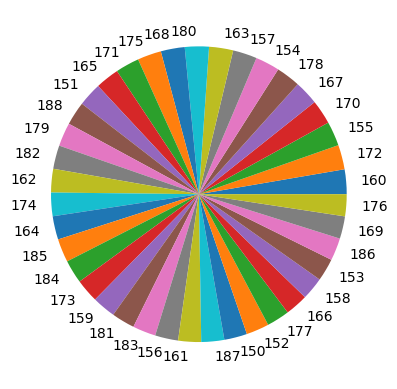

In [205]:
conteo_decadas = data_train["decade"].value_counts()
plt.pie(conteo_decadas,labels=conteo_decadas.index)
plt.show()

In [206]:
data_train["decade"].value_counts(normalize=True)

decade
160    0.027004
172    0.026813
155    0.026622
170    0.026526
167    0.026462
178    0.026462
154    0.026431
157    0.026335
163    0.026335
180    0.026271
168    0.026176
175    0.026017
171    0.025985
165    0.025921
151    0.025857
188    0.025762
179    0.025762
182    0.025730
162    0.025730
174    0.025698
164    0.025603
185    0.025571
184    0.025539
173    0.025539
159    0.025539
181    0.025316
183    0.025284
156    0.025221
161    0.025061
187    0.025061
150    0.025029
152    0.024998
177    0.024902
166    0.024807
158    0.024775
153    0.024679
186    0.024615
169    0.024552
176    0.024010
Name: proportion, dtype: float64

Resumen de lo observado en la exploración de datos:
- No hay falta de datos o datos nulos, y no hay problemas con el formato de las décadas
- A pesar de que algunos textos contienen palabras mal interpretadas o con ruido, en ninguno de los textos se alcanza un 60% de palabras con ruido
- La gran mayoría de los textos tienen ruido bajo o medio, por lo que quizá lo mejor sea omitir aquellos más difíciles de descifrar
- No hay parece haber indicios de una correlación entre el ruido en los textos y la década en las que se clasifican
- No hay desbalance en las categorías, todas tienen una cantidad de datos asociados muy similar

## Preparación de datos

Detalles a revisar de los textos
- Eliminar textos que tengan mucha información con ruido
- Pasar todo a minúscula
- Eliminar signos de puntuación y otros signos como !, ?, ]


In [207]:
# Empezamos eliminando los ejemplos para los cuales categoria_ruido es Alta (esto solo se hará para los datos de entrenamiento)

data_train = data_train[data_train["categoria_ruido"]!="alto"]

In [208]:
# Pasamos todos los textos a minúscula
data_train["text"] = data_train["text"].str.lower()

C:\Users\pifbl\AppData\Local\Temp\ipykernel_2276\1179906870.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train["text"] = data_train["text"].str.lower()


In [ ]:
# Reemplazamos los signos raros y de puntuación por espacios
chars_permanecer = r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ0-9\s]"
# Para el caractér "-" que indica la contuniadad de una pabra el la siguiente línea hacemos una excepción y lo eliminamos
data_train["text"] = data_train["text"].str.replace(r"-\s*\n\s*","",regex=True)
data_train["text"] = data_train["text"].str.replace(chars_permanecer," ",regex=True)
# Arreglamos los espacios para que solo quede uno
data_train["text"] = data_train["text"].str.replace(r"\s+", " ", regex=True).str.strip()

C:\Users\pifbl\AppData\Local\Temp\ipykernel_2276\2124475952.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train["text"] = data_train["text"].str.replace(r"-\s*\n\s*","",regex=True)
C:\Users\pifbl\AppData\Local\Temp\ipykernel_2276\2124475952.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train["text"] = data_train["text"].str.replace(chars_permanecer," ",regex=True)
C:\Users\pifbl\AppData\Local\Temp\ipykernel_2276\2124475952.py:7: SettingWithCopyWarning: 
A value is trying to be set on a

In [210]:
print(data_train["text"][13460])

llegadoata peffection q oeuenios poique pajiédoellacuéia llegaremos nuif mc o síeinpiequetrabajamosenpalfaradelan teiiosalteguramosáno tomar airasuuas enla po a nos paramos luego contenga mosadefcéder paria baro po q cnelcami no delaeir indar tallef que quié fepara es vulfotomaratrasxeltepuestodamancra denegl gécía nofe paltejamasennofotros défcufdo enla virtud ni fegurídadpo mu cboqueaíamos trabajado iuoqrcniose tomaratrasesmeuller comimos elglo riofoapoftollaiití bablocófo mádofecon dios en fu bíuir cada día mase mirando no lo que auí i beepo fino lo q le quedaua po pajer oejia haermanotonopictoquefalla ago a pealcanjado n ida pago vna cofs q oluídandome de todo lo q pefeepo penfandoenloqtne queda po pajer p ollgo niicamínocódeneooealcágaraqueliaalta merced que díosniefeñaloalríépo para elfuf llamado siclbíéaue turadoapollol fant igwblo vafo de efeogímiéto ellandotá vellido oe 5efu cp íllo que ofaua dejír ya no bíuo fo que gefu cp illo es el qúebiue en múempero avn con todo ello pioc

## Construcción modelo de aprendizaje

In [ ]:
stopwords_es = ["yo","mi","conmigo","tú","ti","contigo","vos","él","ella","ello","usted","sí","consigo","nosotros","nosotras",
                "ellos","ellas","ustedes","me","te","nos","lo","la","se","los","las","les","mía","mío","míos","mías","tuyo","tuya","tuyos","tuyas",
                "suyo","suya","suyos","suyas","nuestro","nuestra","nuestros","nuestras","este","esta","esto",
                "estos","estas","ese","eso","esa","esos","esas","aquel","aquello","aquella","aquellos","aquellas","uno","una","unos","unas","otro","otra",
                "otros","otras","cualquiera","cualesquiera",
                "quienquiera","quienesquiera","demás","de","que","en","por","con","del","para","como","pues","pero","porque","muy","mas","era","parte","donde",
                "no","ni","ya","es","al","le","su","ha","si","sus","fue","quien","el","entre","un","bien","dos","tu","don","tiempo"]

X_train_text, X_test_text, y_train, y_test = train_test_split(data_train["text"],data_train["decade"],test_size=0.2,random_state=42)

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words=stopwords_es,
        max_df=0.85,
        min_df=3,
        ngram_range=(1,3),
        max_features=10000
    )),
    ("reg", Ridge())
])

param_grid = {
    "reg__alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_text, y_train)

best_model = grid.best_estimator_

best_model.fit(X_train_text,y_train)

y_pred_cont = best_model.predict(X_test_text)

y_pred = np.round(y_pred_cont).astype(int)
y_pred = np.clip(y_pred, 150, 188)

mae = mean_absolute_error(y_test, y_pred_cont)
print("MAE:", mae)

rmse = root_mean_squared_error(y_test,y_pred_cont)
print("RMSE:",rmse)

MAE: 7.878340414270447
RMSE: 9.543517232004154


## Evaluación del modelo (metricas)

## Procesamiento de datos con el modelo